#### 18.2 鼠标交互
- 当用户触发鼠标事件时，通常要创建一个响应函数 `def OnMouseAction(event, x, y, flags, userdata)`，将要实现的操作写在响应函数内，其中
    - `event` 表示触发何种事件
    - `x, y` 表示触发鼠标事件时，鼠标在窗口中的坐标 (x, y)
    - `flags` 表示鼠标的拖曳事件，以及键盘鼠标联合事件
    - `userdata` 为可选函数，用来接收交互信息
    - `OnMouseAction` 为自定义的响应函数名称；`def` 为定义响应函数所使用的关键字
- 定义响应函数后，要将该函数与一个特定的窗口建立联系(绑定)，让该窗口内的鼠标触发事件时，能够找到该响应函数并执行，可通过`cv2.setMouseCallback(winname, onMouse, userdata)` 来实现，其中：
    - `winname` 是绑定的窗口名
    - `onMouse` 是绑定的响应函数名
    - `userdata` 为可选参数，在多个窗口时，能把窗口信息传递给响应函数 `OnMouseAction()`

In [2]:
# 查看OpenCV支持的鼠标事件
import cv2
events = [i for i in dir(cv2) if 'EVENT' in i]
for e in events:
    print(e)

EVENT_FLAG_ALTKEY
EVENT_FLAG_CTRLKEY
EVENT_FLAG_LBUTTON
EVENT_FLAG_MBUTTON
EVENT_FLAG_RBUTTON
EVENT_FLAG_SHIFTKEY
EVENT_LBUTTONDBLCLK
EVENT_LBUTTONDOWN
EVENT_LBUTTONUP
EVENT_MBUTTONDBLCLK
EVENT_MBUTTONDOWN
EVENT_MBUTTONUP
EVENT_MOUSEHWHEEL
EVENT_MOUSEMOVE
EVENT_MOUSEWHEEL
EVENT_RBUTTONDBLCLK
EVENT_RBUTTONDOWN
EVENT_RBUTTONUP


##### 1. 双击鼠标绘制随机矩形

In [ ]:
import cv2
import numpy as np

d = 400


def draw(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDBLCLK:
        p1x = x
        p1y = y
        p2x = np.random.randint(1, d - 50)
        p2y = np.random.randint(1, d - 50)
        color = np.random.randint(0, high=256, size=(3,)).tolist()
        cv2.rectangle(img, (p1x, p1y), (p2x, p2y), color, 2)


img = np.ones((d, d, 3), dtype="uint8") * 255
cv2.namedWindow("Demo1")
cv2.setMouseCallback("Demo1", draw)
while 1:
    cv2.imshow("Demo1", img)
    if cv2.waitKey(20) == 27:   # ESC 退出
        break
cv2.destroyAllWindows()

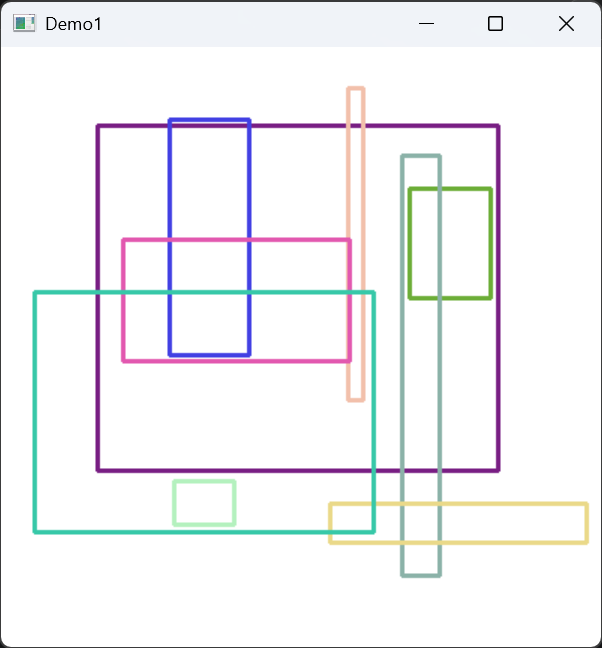

##### 2. 单击鼠标，在不同窗口内绘制圆形

In [ ]:
import numpy as np
import cv2

thickness = -1  # 填充实心圆
d = 400


# 创建回调函数
def OnMouseAction(event, x, y, flags, param):
    img = param
    if event == cv2.EVENT_LBUTTONDOWN:
        r = np.random.randint(1, d / 5)
        color = np.random.randint(0, high=256, size=(3,)).tolist()
        cv2.circle(img, (x, y), r, color, thickness)


img1 = np.zeros((500, 500, 3), np.uint8)
img2 = np.ones((500, 500, 3), np.uint8) * 255
cv2.putText(img1, "A", (50, 450), cv2.FONT_HERSHEY_SIMPLEX, 20, (255, 0, 0), 5)
cv2.putText(img2, "B", (50, 450), cv2.FONT_HERSHEY_SIMPLEX, 20, (255, 0, 0), 5)
cv2.namedWindow("image1")
cv2.namedWindow("image2")
cv2.setMouseCallback("image1", OnMouseAction, img1)
cv2.setMouseCallback("image2", OnMouseAction, img2)

while 1:
    cv2.imshow("image1", img1)
    cv2.imshow("image2", img2)
    k = cv2.waitKey(1)
    if k == ord("q"):
        break
cv2.destroyAllWindows()

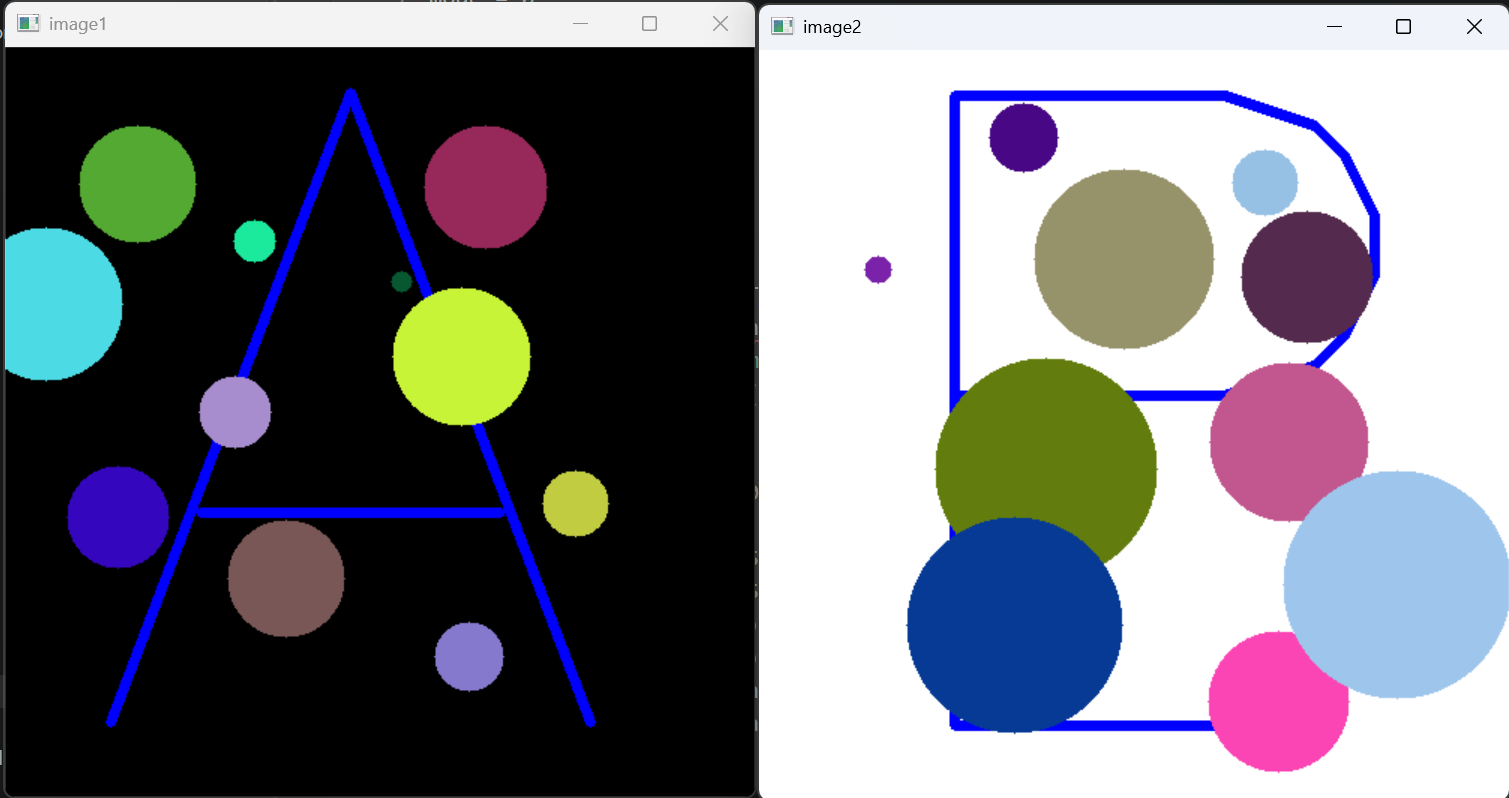

##### 3. 结合键盘和鼠标，绘制不同的图形

In [ ]:
import cv2
import numpy as np

thickness = -1
mode = 1
d = 400


def draw_circle(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        a = np.random.randint(1, d - 50)
        r = np.random.randint(1, d / 5)
        angle = np.random.randint(0, 361)
        color = np.random.randint(0, high=256, size=(3,)).tolist()
        if mode == 1:
            cv2.rectangle(img, (x, y), (a, a), color, thickness)
        elif mode == 2:
            cv2.circle(img, (x, y), r, color, thickness)
        elif mode == 3:
            cv2.line(img, (a, a), (x, y), color, 3)
        elif mode == 4:
            cv2.ellipse(img, (x, y), (100, 150), angle, 0, 360, color, thickness)
        elif mode == 5:
            cv2.putText(img, "OpenCV", (0, round(d/2)), cv2.FONT_HERSHEY_SIMPLEX, 2, color, 5)


img = np.ones((d, d, 3), np.uint8) * 255
cv2.namedWindow("image")
cv2.setMouseCallback("image", draw_circle)
while 1:
    cv2.imshow("image", img)
    k = cv2.waitKey(1) & 0xFF
    if k == ord("r"):
        mode = 1
    elif k == ord("c"):
        mode = 2
    elif k == ord("l"):  # 字母l
        mode = 3
    elif k == ord("e"):
        mode = 4
    elif k == ord("t"):
        mode = 5
    elif k == ord("f"):
        thickness = -1
    elif k == ord("u"):
        thickness = 3
    elif k == 27:  # ESC 退出
        break
cv2.destroyAllWindows()


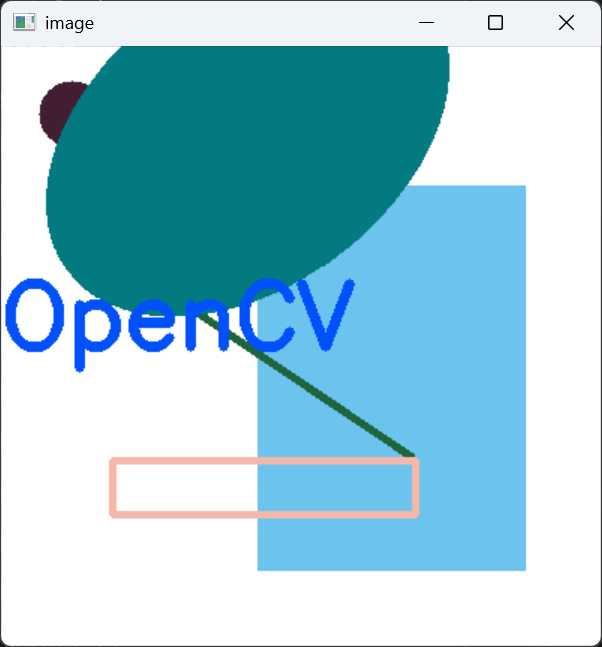